# Segmentación de clientes de tarjetas de crédito

## 02 — Modelado y segmentación

Este notebook utiliza la base procesada en `01_data_preparation.ipynb`
para identificar grupos de clientes con patrones de comportamiento similares.

### Objetivos

- Preparar las variables para métodos basados en distancias.
- Evaluar si los datos presentan estructura agrupable.
- Determinar una cantidad razonable de segmentos.
- Ajustar y evaluar K-Means.
- Interpretar los perfiles obtenidos en las unidades originales.
- Visualizar la estructura multivariada mediante PCA.
- Explorar DBSCAN como método alternativo basado en densidad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns       

# Manejo de rutas de archivos independiente del sistema operativo
from pathlib import Path    

# Algoritmos de clustering
from sklearn.cluster import DBSCAN, KMeans

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

 # Búsqueda de vecinos cercanos
from sklearn.neighbors import NearestNeighbors

# Estandarización de variables
from sklearn.preprocessing import StandardScaler

## 2. Carga de datos procesados

Se utiliza directamente `customers_processed.csv`, generado en el notebook anterior. La limpieza, imputación y eliminación del identificador ya fueron resueltas allí, por lo que no se repite el análisis exploratorio.

In [2]:
DATA_PATH = Path("../data/processed/customers_processed.csv")

df = pd.read_csv(DATA_PATH)

print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 3. Preparación para clustering

### 3.1 Transformación de variables sesgadas

Las variables utilizadas no tienen todas la misma naturaleza:

- **Montos:** saldo, compras, adelantos, límite de crédito y pagos.
- **Conteos:** número de transacciones de compras y adelantos.
- **Frecuencias/proporciones:** variables acotadas principalmente entre 0 y 1.
- **Antigüedad:** `TENURE`, expresada en meses.

La transformación logarítmica se considera principalmente para montos y
conteos no negativos con marcada asimetría positiva. Las frecuencias,
proporciones y `TENURE` conservan su escala original.

Como K-Means se basa en distancias, los valores extremos pueden ejercer una influencia desproporcionada. Se aplica `log1p` únicamente a estas variables, preservando `df` en su escala original para la interpretación posterior de los segmentos.

In [3]:
log_features = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "CASH_ADVANCE_TRX",
    "PURCHASES_TRX",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
]

# Copia destinada al modelado; df conserva las unidades originales.
df_model = df.copy()
df_model[log_features] = np.log1p(df_model[log_features])

In [4]:
skewness_comparison = pd.DataFrame({
    "original": df[log_features].skew(),
    "transformed": df_model[log_features].skew(),
})

skewness_comparison["reduction"] = (
    skewness_comparison["original"].abs()
    - skewness_comparison["transformed"].abs()
)

skewness_comparison.sort_values("original", ascending=False)

,original,transformed,reduction
MINIMUM_PAYMENTS,13.852446,0.269703,13.582743
ONEOFF_PURCHASES,10.045083,0.185854,9.859229
PURCHASES,8.144269,-0.764492,7.379777
INSTALLMENTS_PURCHASES,7.299120,-0.024981,7.274139
PAYMENTS,5.907620,-1.778312,4.129308
CASH_ADVANCE_TRX,5.721298,0.940131,4.781167
CASH_ADVANCE,5.166609,0.262594,4.904015
PURCHASES_TRX,4.630655,0.032697,4.597958
BALANCE,2.393386,-0.861021,1.532365
CREDIT_LIMIT,1.522636,-0.101408,1.421228


La transformación reduce de forma marcada la asimetría absoluta en todas las variables seleccionadas. Esto disminuye la influencia de las colas extremas antes de calcular distancias.

### 3.2 Escalamiento

Tras la transformación, las variables siguen expresadas en rangos distintos. Se estandarizan con `StandardScaler` para que ninguna domine el clustering únicamente por su escala.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=df_model.columns,
    index=df_model.index,
)

## 4. Tendencia a formar clusters

Antes de aplicar K-Means se utiliza la estadística de Hopkins para comprobar si los datos presentan una estructura más agrupada que una distribución aproximadamente aleatoria. En esta implementación, valores cercanos a 0.5 sugieren aleatoriedad y valores próximos a 1 indican mayor tendencia a formar agrupaciones.

In [6]:
def hopkins_statistic(X, sample_size=None, random_state=None):
    """Calcula Hopkins: valores altos indican mayor tendencia a clustering."""
    X = np.asarray(X)
    n_samples, n_features = X.shape

    if sample_size is None:
        sample_size = max(1, int(0.1 * n_samples))

    rng = np.random.default_rng(random_state)
    sample_indices = rng.choice(n_samples, size=sample_size, replace=False)
    X_sample = X[sample_indices]

    random_points = rng.uniform(
        low=X.min(axis=0),
        high=X.max(axis=0),
        size=(sample_size, n_features),
    )

    nn_random = NearestNeighbors(n_neighbors=1).fit(X)
    u_distances, _ = nn_random.kneighbors(random_points)

    # El primer vecino de una observación real es ella misma; se usa el segundo.
    nn_real = NearestNeighbors(n_neighbors=2).fit(X)
    w_distances, _ = nn_real.kneighbors(X_sample)

    u = u_distances[:, 0]
    w = w_distances[:, 1]

    return np.sum(u) / (np.sum(u) + np.sum(w))


hopkins_values = [
    hopkins_statistic(X_scaled, random_state=seed)
    for seed in range(20)
]

print(f"Hopkins promedio: {np.mean(hopkins_values):.3f}")
print(f"Desviación estándar: {np.std(hopkins_values):.3f}")
print(f"Mínimo: {np.min(hopkins_values):.3f}")
print(f"Máximo: {np.max(hopkins_values):.3f}")

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\gba74\.conda\envs\customer-segmentation\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\gba74\.conda\envs\customer-segmentation\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\gba74\.conda\envs\customer-segmentation\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 106: invalid start byte


Hopkins promedio: 0.863
Desviación estándar: 0.002
Mínimo: 0.859
Máximo: 0.868


El Hopkins promedio fue **0.863**, con una desviación estándar de **0.002** y valores entre **0.859 y 0.868**. La estabilidad entre repeticiones y la distancia respecto de 0.5 indican una fuerte tendencia a formar agrupaciones, por lo que resulta razonable continuar con métodos de clustering.

## 5. Selección del número de clusters

Se evalúan soluciones entre `k = 2` y `k = 10` mediante cuatro criterios complementarios: inercia, Silhouette, Calinski-Harabasz y Davies-Bouldin. Ninguna métrica se utiliza de forma aislada.

In [7]:
k_values = range(2, 11)
results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto",
    )
    labels = kmeans.fit_predict(X_scaled)

    results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
    })

cluster_metrics = pd.DataFrame(results)
cluster_metrics

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,113331.718143,0.251507,3064.874283,1.506310
1,3,95644.956110,0.224411,2642.858521,1.681288
2,4,86617.417863,0.212570,2256.111179,1.663198
3,5,77941.153383,0.217832,2129.174530,1.594872
4,6,71656.480711,0.217211,2009.405510,1.467400
5,7,68154.349200,0.205684,1836.940987,1.514505
6,8,66458.647548,0.195194,1647.110309,1.708869
7,9,63504.174947,0.192971,1560.099328,1.689747
8,10,60720.577500,0.173896,1495.702645,1.673044


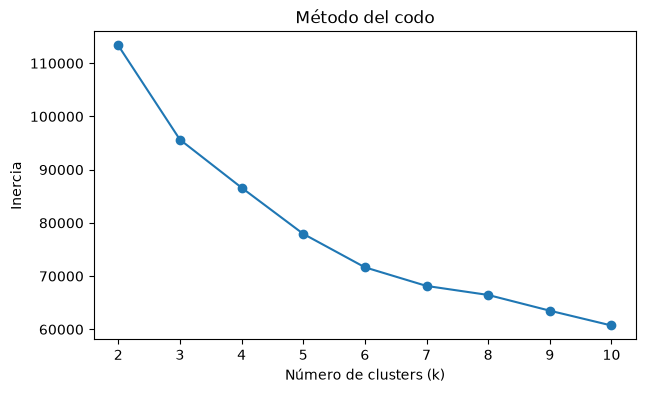

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_metrics["k"], cluster_metrics["inertia"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(cluster_metrics["k"])
plt.show()

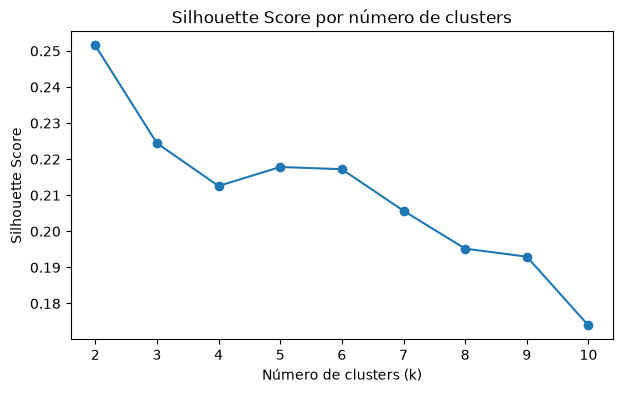

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_metrics["k"], cluster_metrics["silhouette"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por número de clusters")
plt.xticks(cluster_metrics["k"])
plt.show()

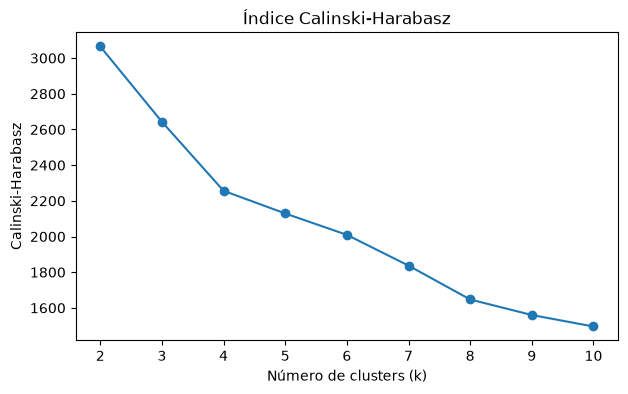

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_metrics["k"], cluster_metrics["calinski_harabasz"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Calinski-Harabasz")
plt.title("Índice Calinski-Harabasz")
plt.xticks(cluster_metrics["k"])
plt.show()

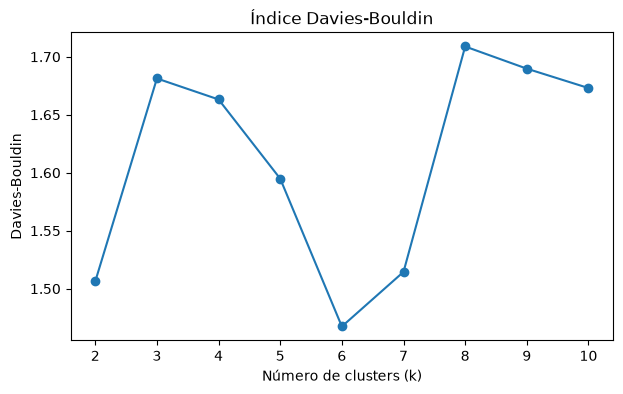

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_metrics["k"], cluster_metrics["davies_bouldin"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Davies-Bouldin")
plt.title("Índice Davies-Bouldin")
plt.xticks(cluster_metrics["k"])
plt.show()

Los criterios no señalan una única solución. `k=2` obtiene el mayor Silhouette (**0.252**) y el mayor Calinski-Harabasz, mientras que `k=6` presenta el menor Davies-Bouldin (**1.467**). Dado que dos grupos resultan demasiado generales para el objetivo de segmentación, se comparan con mayor detalle las soluciones `k=2`, `k=5` y `k=6`.

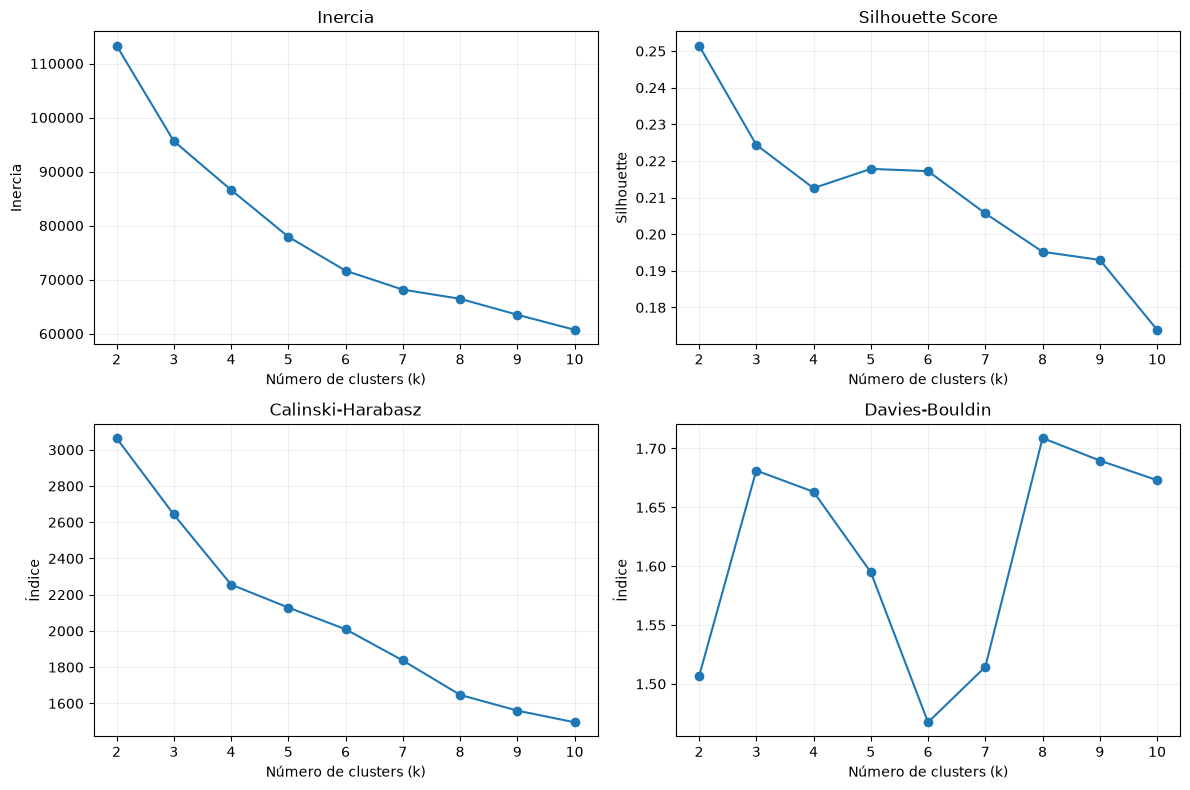

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Inercia
axes[0, 0].plot(
    cluster_metrics["k"],
    cluster_metrics["inertia"],
    marker="o"
)
axes[0, 0].set_title("Inercia")
axes[0, 0].set_xlabel("Número de clusters (k)")
axes[0, 0].set_ylabel("Inercia")

# Silhouette
axes[0, 1].plot(
    cluster_metrics["k"],
    cluster_metrics["silhouette"],
    marker="o"
)
axes[0, 1].set_title("Silhouette Score")
axes[0, 1].set_xlabel("Número de clusters (k)")
axes[0, 1].set_ylabel("Silhouette")

# Calinski-Harabasz
axes[1, 0].plot(
    cluster_metrics["k"],
    cluster_metrics["calinski_harabasz"],
    marker="o"
)
axes[1, 0].set_title("Calinski-Harabasz")
axes[1, 0].set_xlabel("Número de clusters (k)")
axes[1, 0].set_ylabel("Índice")

# Davies-Bouldin
axes[1, 1].plot(
    cluster_metrics["k"],
    cluster_metrics["davies_bouldin"],
    marker="o"
)
axes[1, 1].set_title("Davies-Bouldin")
axes[1, 1].set_xlabel("Número de clusters (k)")
axes[1, 1].set_ylabel("Índice")

for ax in axes.flat:
    ax.set_xticks(cluster_metrics["k"])
    ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "../figures/cluster_selection_metrics.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### 5.1 Tamaño y estabilidad de las soluciones candidatas

Además de las métricas internas, se revisa que los grupos tengan tamaños razonables y que la partición sea reproducible frente a distintas inicializaciones de K-Means.

In [13]:
candidate_k = [2, 5, 6]
cluster_size_results = []

for k in candidate_k:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X_scaled)
    counts = pd.Series(labels).value_counts().sort_index()

    for cluster, count in counts.items():
        cluster_size_results.append({
            "k": k,
            "cluster": cluster,
            "n_customers": count,
            "percentage": count / len(labels) * 100,
        })

cluster_sizes = pd.DataFrame(cluster_size_results)
cluster_sizes.pivot(
    index="cluster",
    columns="k",
    values="percentage",
).round(2)

k,2,5,6
cluster,,,
0,35.34,15.52,13.91
1,64.66,16.76,18.60
2,NaN,26.17,24.50
3,NaN,20.83,15.44
4,NaN,20.73,16.27
5,NaN,NaN,11.27


In [14]:
stability_results = []

for k in candidate_k:
    reference_model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    reference_labels = reference_model.fit_predict(X_scaled)

    ari_values = []
    for seed in range(20):
        model = KMeans(n_clusters=k, random_state=seed, n_init="auto")
        labels = model.fit_predict(X_scaled)
        ari_values.append(adjusted_rand_score(reference_labels, labels))

    stability_results.append({
        "k": k,
        "mean_ARI": np.mean(ari_values),
        "min_ARI": np.min(ari_values),
        "max_ARI": np.max(ari_values),
        "std_ARI": np.std(ari_values),
    })

stability_df = pd.DataFrame(stability_results)
stability_df

,k,mean_ARI,min_ARI,max_ARI,std_ARI
0,2,0.998651,0.993256,1.000000,0.002100
1,5,0.878216,0.575732,1.000000,0.168033
2,6,0.903797,0.613113,0.999198,0.159589


`k=2` es prácticamente invariable entre inicializaciones (`ARI` medio ≈ **0.999**), pero genera una partición muy amplia. Entre las soluciones más detalladas, `k=6` muestra mejor estabilidad media que `k=5` (**0.904** frente a **0.878**) y mantiene grupos representativos, entre aproximadamente **11% y 25%** de la muestra. Por ello se selecciona `k=6` como solución final, privilegiando un equilibrio entre estabilidad, separación e interpretabilidad.

## 6. Modelo K-Means final

In [15]:
final_k = 6

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init="auto",
)

final_labels = kmeans_final.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered["cluster"] = final_labels

cluster_sizes_final = (
    df_clustered["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_sizes_final

cluster
0    13.91
1    18.60
2    24.50
3    15.44
4    16.27
5    11.27
Name: proportion, dtype: float64

Los seis segmentos presentan tamaños relativamente equilibrados: ninguno representa menos del **11%** de los clientes y el mayor concentra cerca del **25%**. Esto reduce la posibilidad de que la solución esté formada por un gran grupo acompañado de clusters residuales.

## 7. Perfilamiento de los segmentos

Los clusters se interpretan utilizando las variables en sus unidades originales y, de forma complementaria, sus medias estandarizadas. Las medias y medianas permiten describir magnitudes reales; el perfil estandarizado facilita identificar qué características sobresalen respecto del promedio general.

In [16]:
cluster_profile_mean = (
    df_clustered
    .groupby("cluster")
    .mean()
    .round(2)
)

display(cluster_profile_mean.T)

cluster,0,1,2,3,4,5
BALANCE,3473.65,414.70,2300.94,1167.68,1572.42,37.41
BALANCE_FREQUENCY,0.97,0.92,0.93,0.94,0.97,0.34
PURCHASES,1361.20,688.79,16.05,676.72,3371.92,254.93
ONEOFF_PURCHASES,763.94,41.13,14.09,606.50,2244.32,144.59
INSTALLMENTS_PURCHASES,597.51,648.54,2.01,70.56,1127.59,110.63
CASH_ADVANCE,2907.27,36.32,2100.51,152.09,77.84,149.57
PURCHASES_FREQUENCY,0.69,0.85,0.02,0.33,0.93,0.27
ONEOFF_PURCHASES_FREQUENCY,0.29,0.03,0.01,0.24,0.67,0.07
PURCHASES_INSTALLMENTS_FREQUENCY,0.51,0.81,0.00,0.09,0.65,0.19
CASH_ADVANCE_FREQUENCY,0.37,0.01,0.29,0.03,0.02,0.02


In [17]:
cluster_profile_median = (
    df_clustered
    .groupby("cluster")
    .median()
    .round(2)
)

display(cluster_profile_median.T)

cluster,0,1,2,3,4,5
BALANCE,2705.15,100.42,1595.98,907.68,762.29,13.36
BALANCE_FREQUENCY,1.00,1.00,1.00,1.00,1.00,0.33
PURCHASES,830.15,480.27,0.00,409.97,2339.06,133.00
ONEOFF_PURCHASES,374.95,0.00,0.00,329.33,1373.92,0.00
INSTALLMENTS_PURCHASES,310.64,449.28,0.00,0.00,692.78,25.58
CASH_ADVANCE,1984.01,0.00,1372.81,0.00,0.00,0.00
PURCHASES_FREQUENCY,0.75,0.92,0.00,0.30,1.00,0.17
ONEOFF_PURCHASES_FREQUENCY,0.20,0.00,0.00,0.17,0.67,0.00
PURCHASES_INSTALLMENTS_FREQUENCY,0.50,0.88,0.00,0.00,0.75,0.08
CASH_ADVANCE_FREQUENCY,0.33,0.00,0.25,0.00,0.00,0.00


In [18]:
print(cluster_profile_median.T.round(2).to_markdown())

|                                  |       0 |       1 |       2 |       3 |       4 |       5 |
|:---------------------------------|--------:|--------:|--------:|--------:|--------:|--------:|
| BALANCE                          | 2705.15 |  100.42 | 1595.98 |  907.68 |  762.29 |   13.36 |
| BALANCE_FREQUENCY                |    1    |    1    |    1    |    1    |    1    |    0.33 |
| PURCHASES                        |  830.15 |  480.27 |    0    |  409.97 | 2339.06 |  133    |
| ONEOFF_PURCHASES                 |  374.95 |    0    |    0    |  329.33 | 1373.92 |    0    |
| INSTALLMENTS_PURCHASES           |  310.64 |  449.28 |    0    |    0    |  692.78 |   25.58 |
| CASH_ADVANCE                     | 1984.01 |    0    | 1372.81 |    0    |    0    |    0    |
| PURCHASES_FREQUENCY              |    0.75 |    0.92 |    0    |    0.3  |    1    |    0.17 |
| ONEOFF_PURCHASES_FREQUENCY       |    0.2  |    0    |    0    |    0.17 |    0.67 |    0    |
| PURCHASES_INSTALLMENTS_FREQU

In [19]:
df_scaled_clustered = X_scaled_df.copy()
df_scaled_clustered["cluster"] = final_labels

cluster_profile_scaled = (
    df_scaled_clustered
    .groupby("cluster")
    .mean()
    .round(2)
)

cluster_profile_scaled

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,0.83,0.41,0.62,0.52,0.49,1.17,0.50,0.30,0.37,1.18,1.27,0.62,0.43,0.53,0.86,-0.39,-0.04
1,-0.63,0.20,0.44,-0.69,0.90,-0.81,0.90,-0.59,1.12,-0.63,-0.74,0.54,-0.45,-0.23,-0.42,0.62,-0.05
2,0.57,0.23,-1.48,-0.84,-1.05,1.02,-1.18,-0.64,-0.91,0.78,0.91,-1.29,-0.07,0.07,0.36,-0.42,-0.09
3,0.17,0.26,0.34,0.63,-0.52,-0.51,-0.40,0.14,-0.68,-0.50,-0.54,-0.11,-0.23,-0.23,-0.01,-0.39,0.09
4,0.20,0.41,0.98,1.23,0.80,-0.72,1.08,1.56,0.72,-0.60,-0.69,1.22,0.66,0.62,-0.03,0.49,0.28
5,-1.75,-2.28,-0.17,-0.31,-0.25,-0.60,-0.56,-0.45,-0.44,-0.55,-0.61,-0.46,-0.27,-1.01,-1.10,0.19,-0.20


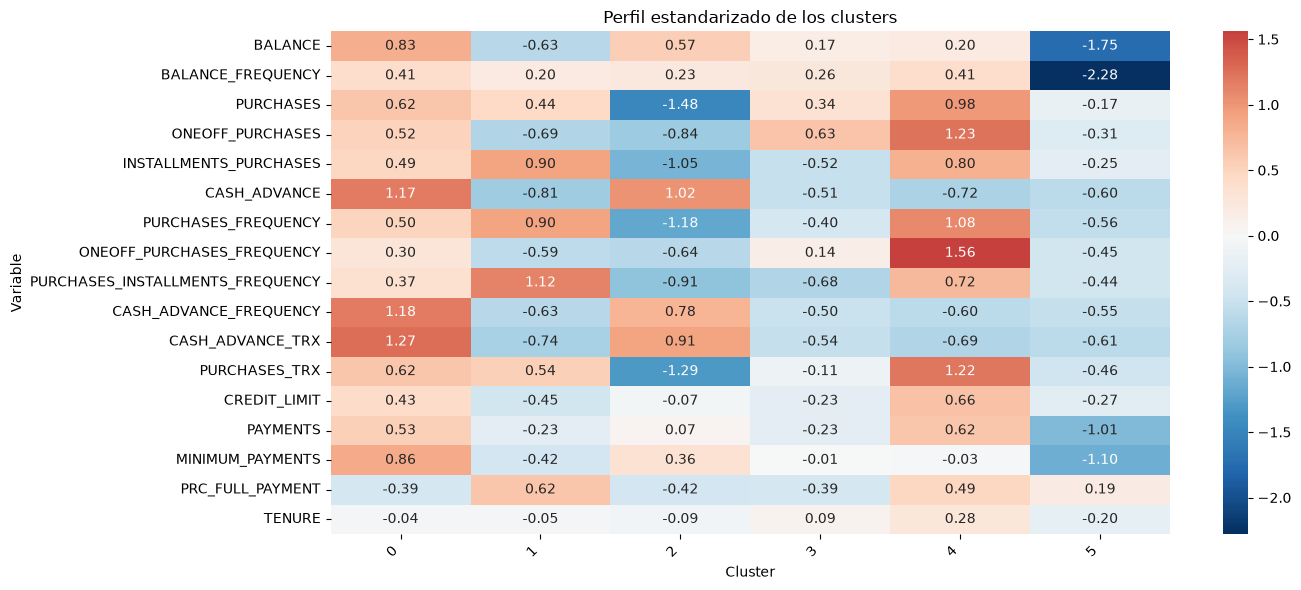

In [20]:

plt.figure(figsize=(14, 6))

sns.heatmap(
    cluster_profile_scaled.T,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Perfil estandarizado de los clusters")
plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "../figures/cluster_profiles_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Las medias y medianas se calculan sobre las variables en sus **unidades
originales**, lo que permite interpretar los perfiles de forma directa.

Como varias variables monetarias presentan distribuciones asimétricas, la
mediana se utiliza para representar el comportamiento típico del cliente,
mientras que la media permite complementar la comparación considerando la
magnitud total de los valores.

El mapa de calor, en cambio, utiliza las **medias de las variables transformadas
y estandarizadas**, es decir, el mismo espacio sobre el cual K-Means construyó
los clusters. Su objetivo es mostrar qué características se encuentran
relativamente por encima o por debajo del promedio.

### Interpretación de los segmentos

- **Cluster 0 — Uso intensivo de adelantos:** saldos altos, elevada frecuencia y número de adelantos de efectivo, junto con actividad de compra por encima del promedio.
- **Cluster 1 — Compradores frecuentes a cuotas:** alta frecuencia de compra y fuerte uso de compras en cuotas, con muy poco uso de adelantos y saldos relativamente bajos.
- **Cluster 2 — Usuarios orientados a adelantos:** prácticamente no realizan compras y concentran su actividad en adelantos de efectivo.
- **Cluster 3 — Compradores ocasionales:** actividad de compra moderada, principalmente puntual, con baja frecuencia y poco uso de adelantos.
- **Cluster 4 — Compradores intensivos:** los mayores niveles de compras, transacciones y frecuencia, con límites de crédito elevados y escaso uso de adelantos.
- **Cluster 5 — Clientes de baja actividad:** bajos saldos, poca frecuencia de uso, pagos reducidos y menor actividad transaccional.

La solución de seis clusters permite distinguir patrones de comportamiento que quedarían ocultos en una segmentación más general.

## 8. Visualización e interpretación mediante PCA

PCA se utiliza aquí como herramienta de visualización e interpretación, no para volver a entrenar K-Means. Las dos primeras componentes resumen la estructura multivariada en un plano bidimensional.

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df.index,
)
pca_df["cluster"] = final_labels

explained_variance = pca.explained_variance_ratio_

print(f"Varianza explicada PC1: {explained_variance[0]:.3f}")
print(f"Varianza explicada PC2: {explained_variance[1]:.3f}")
print(f"Varianza explicada acumulada: {explained_variance.sum():.3f}")

Varianza explicada PC1: 0.339
Varianza explicada PC2: 0.220
Varianza explicada acumulada: 0.558


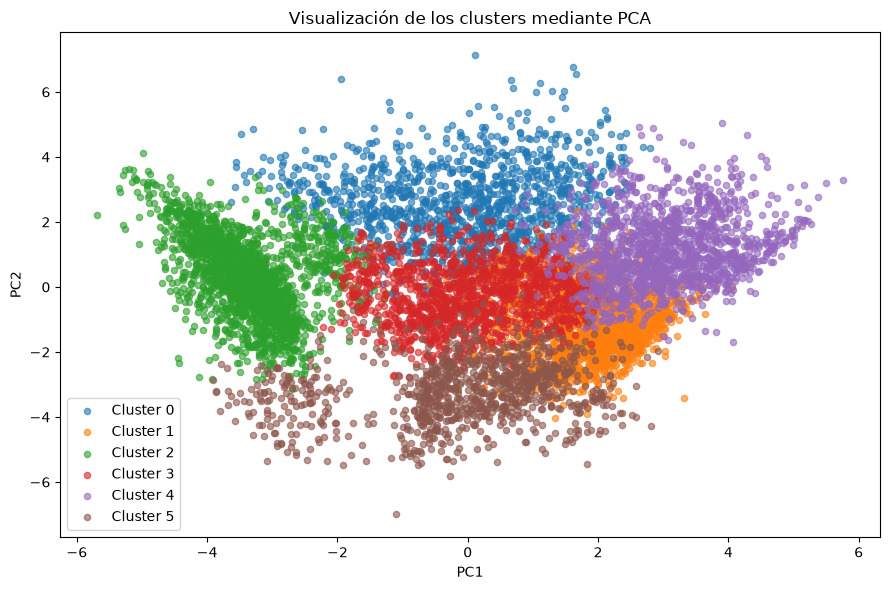

In [22]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6,
        s=20,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualización de los clusters mediante PCA")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../figures/pca_clusters.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

PC1 explica **33.9%** y PC2 **22.0%** de la variabilidad; juntas representan **55.8%**. La proyección muestra separación parcial entre los grupos, pero también solapamiento, algo esperable porque aproximadamente el 44% de la variabilidad queda fuera del plano.

### 8.1 Cargas de las componentes

Las cargas permiten interpretar qué variables definen cada eje. Valores de mayor magnitud absoluta indican mayor influencia; el signo señala la dirección de la relación.

In [23]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X_scaled_df.columns,
)

pca_loadings.round(3)

,PC1,PC2
BALANCE,-0.119,0.437
BALANCE_FREQUENCY,0.022,0.330
PURCHASES,0.364,0.120
ONEOFF_PURCHASES,0.210,0.216
INSTALLMENTS_PURCHASES,0.328,0.073
CASH_ADVANCE,-0.296,0.256
PURCHASES_FREQUENCY,0.368,0.118
ONEOFF_PURCHASES_FREQUENCY,0.221,0.215
PURCHASES_INSTALLMENTS_FREQUENCY,0.314,0.071
CASH_ADVANCE_FREQUENCY,-0.248,0.273


In [24]:
for pc in ["PC1", "PC2"]:
    print(f"\n{pc}")
    display(
        pca_loadings[[pc]]
        .assign(abs_loading=lambda x: x[pc].abs())
        .sort_values("abs_loading", ascending=False)
        .head(10)
    )


PC1


,PC1,abs_loading
PURCHASES_TRX,0.377230,0.377230
PURCHASES_FREQUENCY,0.367590,0.367590
PURCHASES,0.364495,0.364495
INSTALLMENTS_PURCHASES,0.327558,0.327558
PURCHASES_INSTALLMENTS_FREQUENCY,0.313643,0.313643
CASH_ADVANCE,-0.296113,0.296113
CASH_ADVANCE_TRX,-0.277050,0.277050
CASH_ADVANCE_FREQUENCY,-0.248237,0.248237
ONEOFF_PURCHASES_FREQUENCY,0.220637,0.220637
ONEOFF_PURCHASES,0.209887,0.209887



PC2


,PC2,abs_loading
BALANCE,0.436937,0.436937
MINIMUM_PAYMENTS,0.367608,0.367608
BALANCE_FREQUENCY,0.330435,0.330435
PAYMENTS,0.316251,0.316251
CASH_ADVANCE_TRX,0.284246,0.284246
CASH_ADVANCE_FREQUENCY,0.273060,0.273060
CASH_ADVANCE,0.255607,0.255607
CREDIT_LIMIT,0.249699,0.249699
ONEOFF_PURCHASES,0.215586,0.215586
ONEOFF_PURCHASES_FREQUENCY,0.215054,0.215054


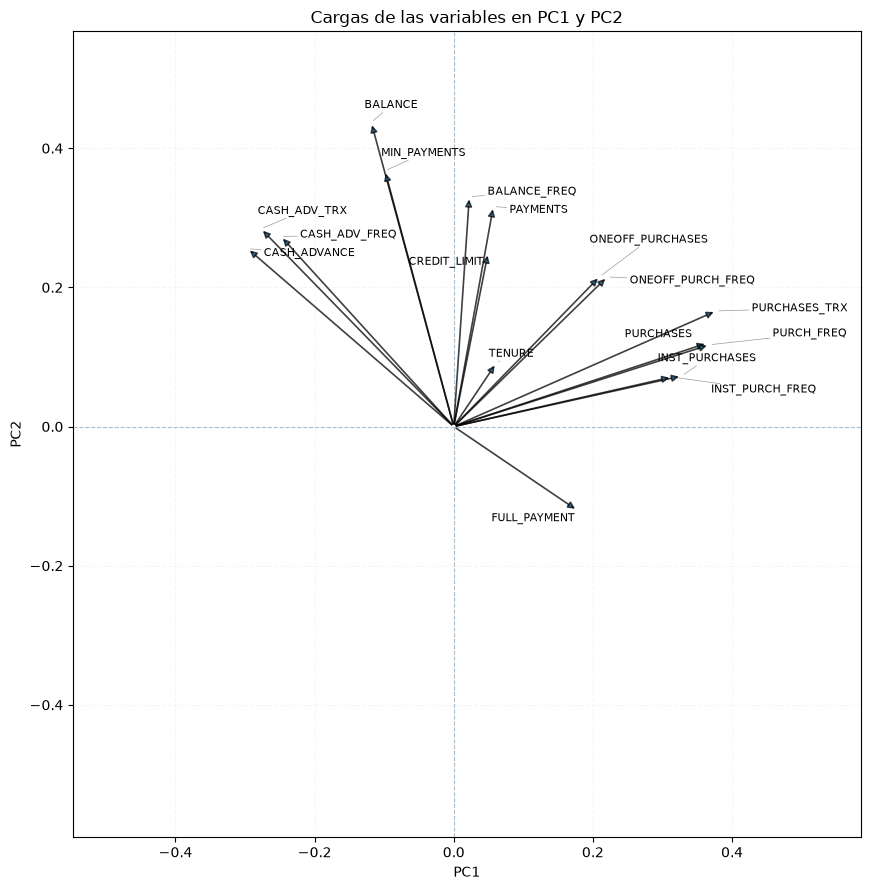

In [25]:
from adjustText import adjust_text

labels_cortos = {
    "CASH_ADVANCE_TRX": "CASH_ADV_TRX",
    "PURCHASES_FREQUENCY": "PURCH_FREQ",
    "MINIMUM_PAYMENTS": "MIN_PAYMENTS",
    "CASH_ADVANCE_FREQUENCY": "CASH_ADV_FREQ",
    "INSTALLMENTS_PURCHASES": "INST_PURCHASES",
    "BALANCE_FREQUENCY": "BALANCE_FREQ",
    "PURCHASES_INSTALLMENTS_FREQUENCY": "INST_PURCH_FREQ",
    "ONEOFF_PURCHASES_FREQUENCY": "ONEOFF_PURCH_FREQ",
    "PRC_FULL_PAYMENT": "FULL_PAYMENT",
}

fig, ax = plt.subplots(figsize=(12, 9))
texts = []

for variable in pca_loadings.index:
    x = pca_loadings.loc[variable, "PC1"]
    y = pca_loadings.loc[variable, "PC2"]

    ax.annotate(
        "",
        xy=(x, y),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="-|>", lw=1.2, alpha=0.75),
    )
    texts.append(
        ax.text(
            x,
            y,
            labels_cortos.get(variable, variable),
            fontsize=8,
            ha="center",
            va="center",
        )
    )

ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.4)
ax.axvline(0, linestyle="--", linewidth=0.8, alpha=0.4)

max_x = pca_loadings["PC1"].abs().max()
max_y = pca_loadings["PC2"].abs().max()
ax.set_xlim(-max_x * 1.45, max_x * 1.55)
ax.set_ylim(-max_y * 1.35, max_y * 1.30)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Cargas de las variables en PC1 y PC2")
ax.grid(alpha=0.12, linestyle="--")
ax.set_aspect("equal", adjustable="box")

adjust_text(
    texts,
    x=pca_loadings["PC1"].values,
    y=pca_loadings["PC2"].values,
    ax=ax,
    expand=(1.15, 1.35),
    force_text=(0.4, 0.7),
    force_pull=(0.02, 0.02),
    max_move=(20, 30),
    arrowprops=dict(arrowstyle="-", linewidth=0.5, alpha=0.4),
)

plt.tight_layout()

plt.savefig(
    "../figures/pca_loadings.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

PC1 está definido principalmente por variables de **actividad de compra** (`PURCHASES_TRX`, frecuencia y monto de compras), mientras que las variables de `CASH_ADVANCE` cargan en dirección opuesta. Por ello puede interpretarse como un eje que contrapone compras frente a adelantos de efectivo.

PC2 está dominado por `BALANCE`, `MINIMUM_PAYMENTS`, `BALANCE_FREQUENCY`, `PAYMENTS` y `CREDIT_LIMIT`, por lo que refleja principalmente el **nivel general de utilización y compromiso financiero** de la tarjeta.

Aunque dos componentes son suficientes para visualizar, la información está distribuida en más dimensiones: **6 componentes explican 84.2%** de la variabilidad y **8 componentes 91.5%**.

## 9. Comparación exploratoria con DBSCAN

Como contraste con K-Means, se evalúa DBSCAN, un algoritmo que identifica
clusters a partir de regiones de alta densidad.

A diferencia de K-Means, DBSCAN no requiere especificar previamente el número
de clusters y puede clasificar como ruido las observaciones que no pertenecen
a una región suficientemente densa.

Su aplicación permite evaluar si los clientes presentan grupos separados por
densidad y no únicamente una partición alrededor de centroides.

### Selección de parámetros

DBSCAN depende de `min_samples`, que determina cuántas observaciones son
necesarias para considerar una región como suficientemente densa, y de `eps`,
que define el radio máximo de vecindad.

Dado que los datos contienen 17 variables, se consideran valores de
`min_samples` relacionados con la dimensionalidad en lugar de fijar
arbitrariamente un valor pequeño.

Para cada alternativa se analiza la distancia al vecino correspondiente
(`k-distance`) como referencia para seleccionar valores plausibles de `eps`.

In [36]:
# n_features = X_scaled.shape[1]

# min_samples_values = [
#     n_features + 1,      # 18
#     2 * n_features       # 34
# ]

# min_samples_values

In [37]:
# # Se considera en esta ocasión como min_samples el doble del número de variables

# min_samples = 2 * X_scaled.shape[1]  # 34

# neighbors = NearestNeighbors(
#     n_neighbors=min_samples
# )

# neighbors.fit(X_scaled)

# distances, _ = neighbors.kneighbors(X_scaled)

# k_distances = np.sort(
#     distances[:, -1]
# )

In [38]:
# eps_values = np.quantile(
#     k_distances,
#     [0.90, 0.925, 0.95, 0.975, 0.99]
# )

# eps_values

In [39]:
dbscan_results = []

n_features = X_scaled.shape[1]

for min_samples in [n_features + 1, 2 * n_features]:

    neighbors = NearestNeighbors(
        n_neighbors=min_samples
    )
    neighbors.fit(X_scaled)

    distances, _ = neighbors.kneighbors(X_scaled)
    k_distances = distances[:, -1]

    eps_values = np.quantile(
        k_distances,
        [0.90, 0.925, 0.95, 0.975, 0.99]
    )

    for eps in eps_values:

        labels = DBSCAN(
            eps=eps,
            min_samples=min_samples
        ).fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        noise_percentage = (
            np.mean(labels == -1) * 100
        )

        dbscan_results.append({
            "min_samples": min_samples,
            "eps": eps,
            "n_clusters": n_clusters,
            "noise_percentage": noise_percentage
        })

dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results.round(3)

,min_samples,eps,n_clusters,noise_percentage
0,18,2.352,2,2.961
1,18,2.515,1,1.788
2,18,2.724,1,1.017
3,18,3.033,1,0.358
4,18,3.455,1,0.034
5,34,2.636,1,2.514
6,34,2.816,2,1.542
7,34,3.060,1,0.726
8,34,3.421,1,0.112
9,34,3.851,1,0.034


In [40]:
candidate_configs = [
    {"min_samples": 18, "eps": 2.352},
    {"min_samples": 34, "eps": 2.816}
]

candidate_results = []

for config in candidate_configs:
    labels = DBSCAN(
        eps=config["eps"],
        min_samples=config["min_samples"]
    ).fit_predict(X_scaled)

    # Distribución de observaciones
    counts = pd.Series(labels).value_counts().sort_index()
    percentages = counts / len(labels) * 100

    # Silhouette excluyendo ruido
    mask = labels != -1
    unique_clusters = np.unique(labels[mask])

    if len(unique_clusters) >= 2:
        sil = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )
    else:
        sil = np.nan

    print(
        f"\nmin_samples={config['min_samples']}, "
        f"eps={config['eps']}"
    )

    display(
        pd.DataFrame({
            "n": counts,
            "percentage": percentages.round(2)
        })
    )

    print(f"Silhouette sin ruido: {sil:.3f}")


min_samples=18, eps=2.352


,n,percentage
-1,264,2.95
0,8670,96.87
1,16,0.18


Silhouette sin ruido: 0.175

min_samples=34, eps=2.816


,n,percentage
-1,138,1.54
0,8797,98.29
1,15,0.17


Silhouette sin ruido: 0.132


### Resultado de DBSCAN

Las únicas configuraciones evaluadas que generaron más de un cluster fueron
analizadas con mayor detalle.

En ambos casos, más del 96% de las observaciones quedaron concentradas en un
único cluster, mientras que el segundo grupo representó menos del 0.2% de la
muestra. Los valores de Silhouette obtenidos al excluir el ruido también fueron
bajos.

Por tanto, aunque DBSCAN permite identificar algunas observaciones periféricas,
no revela una estructura de densidad que produzca segmentos de clientes
suficientemente diferenciados y representativos.

Esto contrasta con K-Means, que proporciona una partición más útil para el
objetivo de segmentación de este conjunto de datos.